
# wMAE Evaluation (√ weighting)

This notebook computes the **weighted Mean Absolute Error (wMAE)** between a **truth** CSV and a **prediction** CSV,
comparing all shared numeric properties **except** `wavelength_range`.

We use the square‑root rebalancing you specified:
\[
w_i=\left(\frac{1}{r_i}\right)\left(\frac{K\sqrt{1/n_i}}{\sum_{j=1}^{K}\sqrt{1/n_j}}\right),
\qquad
\text{wMAE}=\frac{1}{|M|}\sum_{i=1}^{K}w_i\sum_{m\in\text{valid}_i}\lvert y_i(m)-\hat y_i(m)\rvert.
\]


## 1) Configure file paths

In [1]:

# Update these if your files live elsewhere
truth_path = "100testbank.csv"
pred_path  = "100prediction.csv"

# Exclude properties from scoring
exclude = {"wavelength_range"}

print("Truth:", truth_path)
print("Pred :", pred_path)
print("Exclude:", exclude)


Truth: 100testbank.csv
Pred : 100prediction.csv
Exclude: {'wavelength_range'}


## 2) Imports and wMAE function (√ weighting)

In [2]:

import math
from typing import List, Optional, Set

import numpy as np
import pandas as pd
from IPython.display import display

def _find_join_key(truth_cols: List[str], pred_cols: List[str], id_cols: Optional[List[str]] = None) -> Optional[str]:
    cand = id_cols if id_cols else ["SMILES", "smiles", "ID", "id", "Name", "name"]
    for c in cand:
        if c in truth_cols and c in pred_cols:
            return c
    return None

def compute_wmae(truth_path: str,
                 pred_path: str,
                 id_cols: Optional[List[str]] = None,
                 exclude: Optional[Set[str]] = None,
                 return_details: bool = False):
    exclude = set(exclude or set())
    truth = pd.read_csv(truth_path)
    pred  = pd.read_csv(pred_path)

    # Align rows by ID if possible, else by position (with length check)
    join_key = _find_join_key(list(truth.columns), list(pred.columns), id_cols)
    if join_key:
        merged = pd.merge(truth, pred, on=join_key, how="inner", suffixes=("", "__pred"))
        M = len(merged)
    else:
        if len(truth) != len(pred):
            raise ValueError("No shared identifier found and row counts differ; provide an ID column to join.")
        merged = pd.concat([truth.reset_index(drop=True),
                            pred.reset_index(drop=True).add_suffix("__pred")], axis=1)
        M = len(merged)

    # Choose comparable numeric properties
    props = []
    for col in truth.columns:
        if col == join_key:
            continue
        if col in exclude:
            continue
        pred_col = f"{col}__pred"
        if pred_col not in merged.columns:
            continue
        t_vals = pd.to_numeric(merged[col], errors="coerce")
        p_vals = pd.to_numeric(merged[pred_col], errors="coerce")
        if t_vals.notna().any() and p_vals.notna().any():
            props.append(col)

    if not props:
        raise ValueError("No comparable numeric properties found after exclusions.")

    K = len(props)

    sqrt_inv_ns = []
    rows = []
    for col in props:
        t = pd.to_numeric(merged[col], errors="coerce")
        p = pd.to_numeric(merged[f"{col}__pred"], errors="coerce")
        mask = t.notna() & p.notna()
        ni = int(mask.sum())
        if ni == 0:
            rows.append(dict(property=col, ni=0, ri=np.nan, sqrt_inv_ni=0.0, weight=0.0, abs_err_sum=0.0))
            sqrt_inv_ns.append(0.0)
            continue
        t_valid = t[mask]
        p_valid = p[mask]
        abs_err_sum = (t_valid - p_valid).abs().sum()
        ri = float(t_valid.max() - t_valid.min())
        sqrt_inv_ni = math.sqrt(1.0 / ni)
        sqrt_inv_ns.append(sqrt_inv_ni)
        rows.append(dict(property=col, ni=ni, ri=ri, sqrt_inv_ni=sqrt_inv_ni, weight=np.nan, abs_err_sum=float(abs_err_sum)))

    denom = float(sum(sqrt_inv_ns)) if sum(sqrt_inv_ns) > 0 else 1.0
    for d in rows:
        ri = d["ri"]; ni = d["ni"]
        if ni == 0 or (ri is None) or (not isinstance(ri, (int, float))) or (ri == 0) or (isinstance(ri, float) and math.isnan(ri)):
            d["weight"] = 0.0
        else:
            d["weight"] = (1.0 / ri) * (K * d["sqrt_inv_ni"] / denom)

    if M == 0:
        raise ValueError("|M| is zero after alignment.")
    wmae_num = sum(d["weight"] * d["abs_err_sum"] for d in rows)
    wmae = wmae_num / M

    details_df = pd.DataFrame(rows, columns=["property", "ni", "ri", "sqrt_inv_ni", "weight", "abs_err_sum"]).sort_values("property")
    if return_details:
        return wmae, M, K, wmae_num, details_df
    return wmae


## 3) Compute wMAE

In [3]:

wmae, M, K, wmae_num, details_df = compute_wmae(truth_path, pred_path, exclude=exclude, return_details=True)

print(f"wMAE = {wmae:.10f}")
print(f"|M| (rows evaluated) = {M}")
print(f"K (num properties) = {K}")
print(f"Sum_i w_i * sum_m |err| = {wmae_num:.10f}")

display(details_df)


wMAE = 0.1480069805
|M| (rows evaluated) = 100
K (num properties) = 10
Sum_i w_i * sum_m |err| = 14.8006980524


,property,ni,ri,sqrt_inv_ni,weight,abs_err_sum
3,BoilingPoint,92,539.4600,0.104257,0.001819,143.8000
0,CrystalSolubility,58,756820.5871,0.131306,0.000002,223327.7842
9,ISC(S1-T1),62,0.1500,0.127000,7.968157,0.3391
2,Log_P,100,9.4040,0.100000,0.100077,2.4847
1,Molecular_Weight,100,401.9200,0.100000,0.002342,4.0300
8,SA_score,100,0.4374,0.100000,2.151623,0.7362
7,Tox_score,100,0.4281,0.100000,2.198365,1.9423
4,is_aromatic,100,1.0000,0.100000,0.941120,0.0000
6,max_sigma,100,390.6900,0.100000,0.002409,1288.9600
5,sigma_780nm,100,352.6360,0.100000,0.002669,845.1530


## 4) Save per‑property breakdown

In [4]:

from pathlib import Path
out_csv = Path("wmae_details_sqrt.csv")
details_df.to_csv(out_csv, index=False)
print("Saved details to:", out_csv)


Saved details to: wmae_details_sqrt.csv


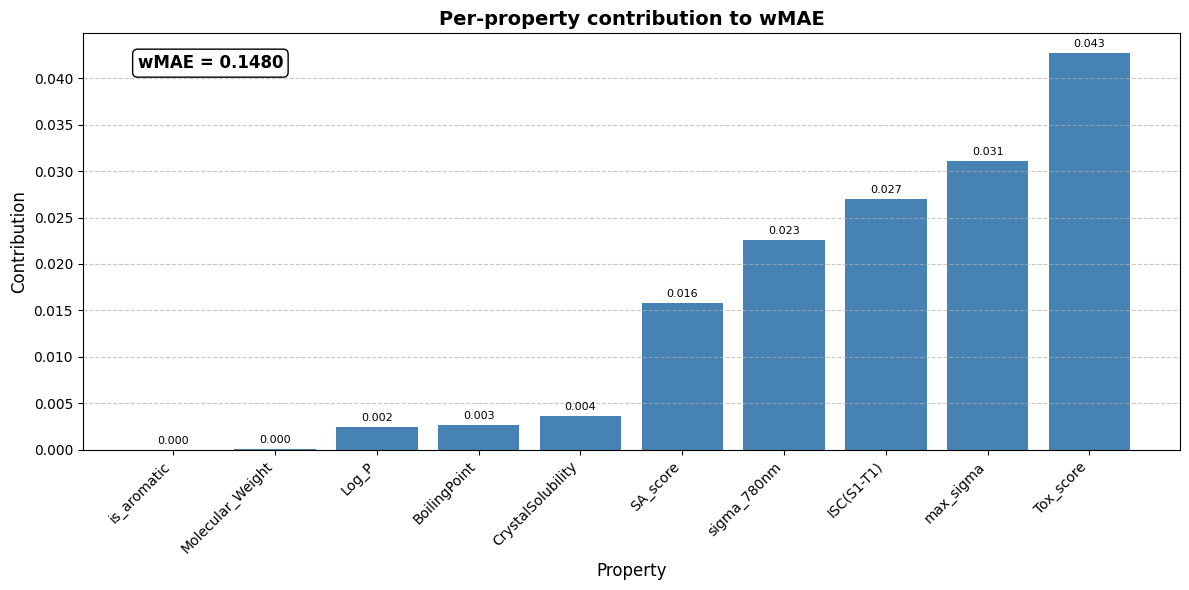

In [6]:
import matplotlib.pyplot as plt

# Compute contribution
contrib = details_df.assign(
    contribution=lambda d: d["weight"] * d["abs_err_sum"] / M
)

# Sort by contribution (ascending)
contrib_sorted = contrib.sort_values("contribution", ascending=True)

plt.figure(figsize=(12, 6))
bars = plt.bar(
    contrib_sorted["property"],
    contrib_sorted["contribution"],
    color="steelblue"
)

# Add labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01 * contrib_sorted["contribution"].max(),  # small offset
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add text box in upper-left corner
plt.gca().text(
    0.05, 0.95,                       # x, y (in axes fraction coords)
    "wMAE = 0.1480",                  # text
    ha="left", va="top",              # anchor to top-left
    transform=plt.gca().transAxes,    # relative to axes (0–1)
    fontsize=12, weight="bold",
    bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3")
)


plt.xticks(rotation=45, ha="right")
plt.title("Per-property contribution to wMAE", fontsize=14, weight="bold")
plt.xlabel("Property", fontsize=12)
plt.ylabel("Contribution", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

# Save outputs
plt.savefig("wmae_contribution.png", dpi=300, bbox_inches="tight")
plt.savefig("wmae_contribution.pdf", dpi=600, bbox_inches="tight")  # high-res PDF
plt.show()